<h3 style='color:blue' align='center'>Handling imbalanced data in customer churn prediction</h3>

Customer churn prediction is to measure why customers are leaving a business. In this tutorial we will be looking at customer churn in telecom business. We will build a deep learning model to predict the churn and use precision,recall, f1-score to measure performance of our model.
We will then handle imbalance in data using various techniques and improve f1-score

- Here same problem solved by 
    - 1.ANN 
    - 2.Logistic Regression

## Methods followed for Imbalanced dat
- 1. Under Sampling
- 2. Over Sampling
- 3. SMOTE Sampling


##### 1st we need to split the data as train test and then do over or undersampling only on train data, not on test. Then compare f1 score in test after this way

- We should perform under / over sample (including SMOTE) only on training data, and measure f1 on original data distribution (test data). Moreover, if you divide oversample data with train_test_split then you have no control over the distribution of duplicated items for test and train. Which means that you can have the same observation in both test and train, which means you test partially on the training set - that's why the results increase. So first divide into train / test, and then perform operations only on the training set, and the test set should be without any changes. 

In [284]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [285]:
import warnings
warnings.filterwarnings('ignore')

**Load the data**

In [286]:
df = pd.read_csv("customer_churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6780,3640-JQGJG,Male,0,Yes,Yes,13,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),44.80,559.2,No
6175,4377-VDHYI,Male,0,Yes,Yes,32,Yes,No,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,90.80,3023.85,No
4503,9658-WYUFB,Female,0,No,No,17,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,94.40,1617.5,Yes
352,4115-NZRKS,Female,1,No,No,7,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.15,574.35,No
4268,5198-HQAEN,Male,0,Yes,Yes,35,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,One year,Yes,Electronic check,89.70,3165.6,No


In [287]:
df.Churn.value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

> Here data is imbalanced

In [288]:
517400/df.shape[0]

73.46301292063042

### EDA - DATA PRE PROCESSING

**First of all, drop customerID column as it is of no use**

In [289]:
df.drop('customerID',axis='columns',inplace=True)

In [290]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

**Quick glance at above makes me realize that TotalCharges should be float but it is an object. Let's check what's going on with  this column**

In [291]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

**Ahh... it is string. Lets convert it to numbers**

In [292]:
pd.to_numeric(df.TotalCharges,errors='coerce').isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [293]:
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [294]:
df.shape

(7043, 20)

In [295]:
df.iloc[488].TotalCharges

' '

In [296]:
df[df.TotalCharges!=' '].shape

(7032, 20)

**Remove rows with space in TotalCharges**

In [297]:
df1 = df[df.TotalCharges!=' ']
df1.shape

(7032, 20)

In [298]:
df1.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [299]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

In [300]:
df1.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [301]:
df1[df1.Churn=='No']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


**Data Visualization**

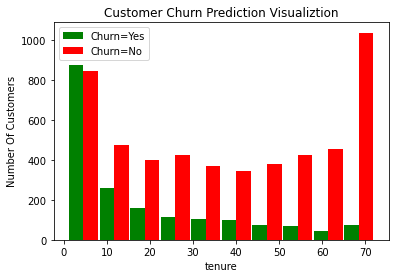

In [302]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

blood_sugar_men = [113, 85, 90, 150, 149, 88, 93, 115, 135, 80, 77, 82, 129]
blood_sugar_women = [67, 98, 89, 120, 133, 150, 84, 69, 89, 79, 120, 112, 100]

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()

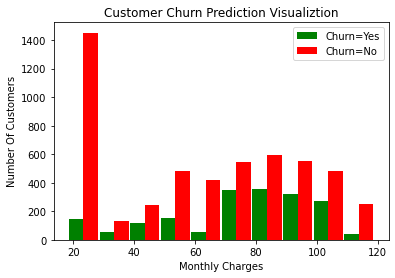

In [303]:
mc_churn_no = df1[df1.Churn=='No'].MonthlyCharges      
mc_churn_yes = df1[df1.Churn=='Yes'].MonthlyCharges      

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

blood_sugar_men = [113, 85, 90, 150, 149, 88, 93, 115, 135, 80, 77, 82, 129]
blood_sugar_women = [67, 98, 89, 120, 133, 150, 84, 69, 89, 79, 120, 112, 100]

plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()

**Many of the columns are yes, no etc. Let's print unique values in object columns to see data values**

In [304]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}') 

In [305]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


**Some of the columns have no internet service or no phone service, that can be replaced with a simple No**

In [306]:
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)

In [307]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


**Convert Yes and No to 1 or 0**

In [308]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)

In [309]:
for col in df1:
    print(f'{col}: {df1[col].unique()}') 

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [310]:
df1['gender'].replace({'Female':1,'Male':0},inplace=True)

In [311]:
df1.gender.unique()

array([1, 0], dtype=int64)

**One hot encoding for categorical columns**

In [312]:
df2 = pd.get_dummies(data=df1, columns=['InternetService','Contract','PaymentMethod'])
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [313]:
df2.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4360,0,1,1,0,31,1,1,1,0,0,...,0,1,0,1,0,0,0,0,1,0
2240,1,1,1,1,72,1,1,1,1,1,...,1,0,0,0,0,1,0,1,0,0
4960,0,1,0,0,50,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
531,0,0,1,1,70,1,0,0,0,0,...,0,0,1,0,0,1,0,1,0,0
2549,0,0,0,0,2,1,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1


In [314]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          uint8
InternetService_Fiber optic                  uint8
InternetService_No             

In [315]:
#Scale the data
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [316]:
for col in df2:
    print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.         0.46478873 0.01408451 0.61971831 0.09859155 0.29577465
 0.12676056 0.38028169 0.85915493 0.16901408 0.21126761 0.8028169
 0.67605634 0.33802817 0.95774648 0.71830986 0.98591549 0.28169014
 0.15492958 0.4084507  0.64788732 1.         0.22535211 0.36619718
 0.05633803 0.63380282 0.14084507 0.97183099 0.87323944 0.5915493
 0.1971831  0.83098592 0.23943662 0.91549296 0.11267606 0.02816901
 0.42253521 0.69014085 0.88732394 0.77464789 0.08450704 0.57746479
 0.47887324 0.66197183 0.3943662  0.90140845 0.52112676 0.94366197
 0.43661972 0.76056338 0.50704225 0.49295775 0.56338028 0.07042254
 0.04225352 0.45070423 0.92957746 0.30985915 0.78873239 0.84507042
 0.18309859 0.26760563 0.73239437 0.54929577 0.81690141 0.32394366
 0.6056338  0.25352113 0.74647887 0.70422535 0.35211268 0.53521127]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [

### Train test split

In [317]:
df22 = df2.copy()


from sklearn.model_selection import train_test_split
train, test = train_test_split(df22 , test_size=0.2, random_state=15, stratify=y)

train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
684,1,0,0,0,0.000000,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
2446,1,0,0,0,0.239437,1,1,0,1,0,...,0,1,0,1,0,0,0,1,0,0
1680,0,0,1,1,0.774648,1,1,0,0,0,...,0,0,1,0,1,0,0,0,0,1
2220,0,0,1,0,1.000000,1,0,1,1,0,...,1,0,0,0,0,1,1,0,0,0
2842,1,0,0,0,0.042254,0,0,1,0,1,...,1,0,0,1,0,0,0,0,0,1


- stratify=y means whatever class of data we have in y (here its Fraud, Not Fraud) that should be equally split in Xtrain and Xtest i.e both Xtrain and Xtest both should have Fraud and NonFraud data. This is to avoid the scenario where in  Xtrain has all Not Fraud data and Xtest has Fraud data. To avoid this type of split we need to specify stratify=y. 
- Its better to specify this instruction when we invoke any model, especially when we have less data.

In [318]:
train.shape,test.shape

((5625, 27), (1407, 27))

In [319]:
# Split train and test data  X and y 
X_train = train.drop('Churn',axis='columns')
y_train = testLabels = train.Churn.astype(np.float32)

X_test = test.drop('Churn',axis='columns')
y_test = testLabels = test.Churn.astype(np.float32)

#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [320]:
y_train.value_counts()

0.0    4130
1.0    1495
Name: Churn, dtype: int64

In [321]:
y.value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

In [322]:
5163/1869

2.7624398073836276

In [323]:
y_test.value_counts()

0.0    1033
1.0     374
Name: Churn, dtype: int64

In [324]:
X_train.shape

(5625, 26)

In [325]:
X_test.shape

(1407, 26)

In [326]:
X_train[:10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
684,1,0,0,0,0.000000,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
2446,1,0,0,0,0.239437,1,1,0,1,0,...,0,1,0,1,0,0,0,1,0,0
1680,0,0,1,1,0.774648,1,1,0,0,0,...,0,0,1,0,1,0,0,0,0,1
2220,0,0,1,0,1.000000,1,0,1,1,0,...,1,0,0,0,0,1,1,0,0,0
2842,1,0,0,0,0.042254,0,0,1,0,1,...,1,0,0,1,0,0,0,0,0,1
5131,1,0,1,0,0.605634,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4372,0,0,1,1,0.000000,1,0,0,0,0,...,0,0,1,1,0,0,1,0,0,0
4687,0,0,1,0,0.295775,1,0,0,0,1,...,0,1,0,1,0,0,0,1,0,0
2385,1,0,0,1,0.028169,0,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
6773,0,1,1,0,0.507042,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [327]:
len(X_train.columns)

26

## 1. Build a model (ANN) in tensorflow/keras**

In [328]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix , classification_report

In [329]:
# !pip install tensorflow-addons

In [330]:
from tensorflow_addons import losses

ModuleNotFoundError: No module named 'tensorflow_addons'

In [331]:
def ANN(X_train, y_train, X_test, y_test, loss, weights):
    model = keras.Sequential([
        keras.layers.Dense(26, input_dim=26, activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    
    if weights == -1:
        model.fit(X_train, y_train, epochs=100)
    else:
        model.fit(X_train, y_train, epochs=100, class_weight = weights)
    
    print(model.evaluate(X_test, y_test))
    
    y_preds = model.predict(X_test)
    y_preds = np.round(y_preds)
    
    print("Classification Report: \n", classification_report(y_test, y_preds))
    
    return y_preds

In [332]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
176/176 [==============================] - 1s 943us/step - loss: 0.4775 - accuracy: 0.7616
Epoch 2/100
176/176 [==============================] - 0s 907us/step - loss: 0.4295 - accuracy: 0.7941
Epoch 3/100
176/176 [==============================] - 0s 864us/step - loss: 0.4214 - accuracy: 0.8016
Epoch 4/100
176/176 [==============================] - 0s 870us/step - loss: 0.4167 - accuracy: 0.8030
Epoch 5/100
176/176 [==============================] - 0s 909us/step - loss: 0.4131 - accuracy: 0.8060
Epoch 6/100
176/176 [==============================] - 0s 945us/step - loss: 0.4115 - accuracy: 0.8046
Epoch 7/100
176/176 [==============================] - 0s 892us/step - loss: 0.4094 - accuracy: 0.8043
Epoch 8/100
176/176 [==============================] - 0s 901us/step - loss: 0.4077 - accuracy: 0.8096
Epoch 9/100
176/176 [==============================] - 0s 899us/step - loss: 0.4070 - accuracy: 0.8094
Epoch 10/100
176/176 [==============================] - 0s 1ms/step - los

176/176 [==============================] - 0s 922us/step - loss: 0.3530 - accuracy: 0.8283
Epoch 80/100
176/176 [==============================] - 0s 845us/step - loss: 0.3525 - accuracy: 0.8324
Epoch 81/100
176/176 [==============================] - 0s 832us/step - loss: 0.3512 - accuracy: 0.8297
Epoch 82/100
176/176 [==============================] - 0s 870us/step - loss: 0.3506 - accuracy: 0.8281
Epoch 83/100
176/176 [==============================] - 0s 856us/step - loss: 0.3516 - accuracy: 0.8288
Epoch 84/100
176/176 [==============================] - 0s 913us/step - loss: 0.3511 - accuracy: 0.8311
Epoch 85/100
176/176 [==============================] - 0s 868us/step - loss: 0.3497 - accuracy: 0.8306
Epoch 86/100
176/176 [==============================] - 0s 838us/step - loss: 0.3494 - accuracy: 0.8283
Epoch 87/100
176/176 [==============================] - 0s 905us/step - loss: 0.3492 - accuracy: 0.8341
Epoch 88/100
176/176 [==============================] - 0s 856us/step - loss:

> Here f1 score of class=1 is 0.55, its very less

## 2. Logistic Regression

- Its a Binary problem, so applied Logistic Regression

In [333]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def log_reg(X_train, y_train, X_test, y_test, weights):
    if weights==-1:
        model = LogisticRegression()
    else:
        model = LogisticRegression(class_weight={0:weights[0], 1:weights[1]})

    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print("Accuracy", acc, "\n")

    y_pred = model.predict(X_test)
    print("preds", y_pred[:5], "\n")

    cl_rep = classification_report(y_test,y_pred)
    print(cl_rep)
    return y_pred
    
    

In [334]:
#weights = -1 # pass -1 to use Logistics Regression without weights
log_reg(X_train, y_train, X_test, y_test, -1)

Accuracy 0.8031272210376688 

preds [0. 0. 0. 0. 1.] 

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.66      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

> Here f1 score of class=1 is 0.59, its very less

## Mitigating Skewness of Data -  IMBALANCE DATA HANDLING

#### Use below all methods on Train data not on whole data

### Method 1: Undersampling

reference: https://www.kaggle.com/rafjaa/resampling-strategies-for-imbalanced-datasets

In [335]:
# Split train and test data  X and y 
#X_train = train.drop('Churn',axis='columns')
#y_train = testLabels = train.Churn.astype(np.float32)

#X_test = test.drop('Churn',axis='columns')
#y_test = testLabels = test.Churn.astype(np.float32)

In [336]:
# Class count
count_class_0, count_class_1 = y_train.value_counts()

# Divide by class
train_class_0 = train[train['Churn'] == 0]
train_class_1 = train[train['Churn'] == 1]

In [337]:
count_class_0, count_class_1  # it's imbalanced.

(4130, 1495)

In [338]:
train_class_0.shape, train_class_1.shape

((4130, 27), (1495, 27))

In [339]:
# Undersample 0-class and concat the DataFrames of both class

train_class_0_under = train_class_0.sample(count_class_1)

train_data_under = pd.concat([train_class_0_under, train_class_1], axis=0)

print('Random under-sampling:')
print(train_data_under.Churn.value_counts())

Random under-sampling:
0    1495
1    1495
Name: Churn, dtype: int64


In [340]:
#Split the train_under data as X_train and y_train
X_train_under = train_data_under.drop('Churn',axis='columns')
y_train_under = train_data_under['Churn']

# Test data to X_test and y_test already done above

In [341]:
# Number of classes in training Data
y_train_under.value_counts()

0    1495
1    1495
Name: Churn, dtype: int64

In [342]:
# Number of classes in training Data  - earlier
y_train.value_counts()

0.0    4130
1.0    1495
Name: Churn, dtype: int64

##  UNDER SAMPLING - ANN
**Printing Classification in the last, Scroll down till the last epoch to watch the classification report**

In [343]:
y_preds = ANN(X_train_under, y_train_under, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
94/94 [==============================] - 0s 831us/step - loss: 0.6276 - accuracy: 0.6659
Epoch 2/100
94/94 [==============================] - 0s 997us/step - loss: 0.5173 - accuracy: 0.7518
Epoch 3/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4978 - accuracy: 0.7562
Epoch 4/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4904 - accuracy: 0.7599
Epoch 5/100
94/94 [==============================] - 0s 914us/step - loss: 0.4861 - accuracy: 0.7649
Epoch 6/100
94/94 [==============================] - 0s 968us/step - loss: 0.4821 - accuracy: 0.7652
Epoch 7/100
94/94 [==============================] - 0s 860us/step - loss: 0.4803 - accuracy: 0.7642
Epoch 8/100
94/94 [==============================] - 0s 989us/step - loss: 0.4792 - accuracy: 0.7669
Epoch 9/100
94/94 [==============================] - 0s 957us/step - loss: 0.4762 - accuracy: 0.7669
Epoch 10/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4748 - accuracy: 0.

94/94 [==============================] - 0s 1ms/step - loss: 0.4006 - accuracy: 0.8147
Epoch 83/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3986 - accuracy: 0.8117
Epoch 84/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3985 - accuracy: 0.8167
Epoch 85/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3974 - accuracy: 0.8167
Epoch 86/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4004 - accuracy: 0.8137
Epoch 87/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3948 - accuracy: 0.8174
Epoch 88/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3965 - accuracy: 0.8177
Epoch 89/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3956 - accuracy: 0.8147
Epoch 90/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3949 - accuracy: 0.8174
Epoch 91/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3926 - accuracy: 0.8214
Epoch 92/100


- ANN: Check classification report above. f1-score for minority class 1 improved from **0.56 to 0.60**. But normally it will be high, here little change

##  UNDER SAMPLING - Log Reg

In [344]:
log_reg(X_train_under, y_train_under, X_test, y_test, -1)

Accuracy 0.7405828002842928 

preds [0 0 0 0 1] 

              precision    recall  f1-score   support

         0.0       0.90      0.73      0.80      1033
         1.0       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

- Log Reg: Check classification report above. f1-score for minority class 1 improved from **0.59 to 0.60**. But normally it will be high, here little change

### Method2: Oversampling

In [345]:
# Oversample 1-class and concat the DataFrames of both classes
train_class_1_over = train_class_1.sample(count_class_0, replace=True)
train_data_over = pd.concat([train_class_0, train_class_1_over], axis=0)

print('Random over-sampling:')
print(train_data_over.Churn.value_counts())

Random over-sampling:
0    4130
1    4130
Name: Churn, dtype: int64


In [346]:
#Split the train_under data as X_train and y_train
X_train_over = train_data_under.drop('Churn',axis='columns')
y_train_over = train_data_under['Churn']

# Test data to X_test and y_test already done above

In [347]:
# Number of classes in training Data
y_train.value_counts()

0.0    4130
1.0    1495
Name: Churn, dtype: int64

##  OVER SAMPLING - ANN

In [348]:
loss = keras.losses.BinaryCrossentropy()
weights = -1
y_preds = ANN(X_train_over, y_train_over, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
94/94 [==============================] - 1s 1ms/step - loss: 0.6006 - accuracy: 0.7074
Epoch 2/100
94/94 [==============================] - 0s 1ms/step - loss: 0.5102 - accuracy: 0.7559
Epoch 3/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4940 - accuracy: 0.7592
Epoch 4/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4865 - accuracy: 0.7605
Epoch 5/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4840 - accuracy: 0.7619
Epoch 6/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4807 - accuracy: 0.7649
Epoch 7/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4806 - accuracy: 0.7619
Epoch 8/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4763 - accuracy: 0.7656
Epoch 9/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4751 - accuracy: 0.7679
Epoch 10/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4746 - accuracy: 0.7669
Epoch 11/

94/94 [==============================] - 0s 1ms/step - loss: 0.4011 - accuracy: 0.8074
Epoch 83/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4021 - accuracy: 0.8127
Epoch 84/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3999 - accuracy: 0.8067
Epoch 85/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3998 - accuracy: 0.8110
Epoch 86/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3995 - accuracy: 0.8097
Epoch 87/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3993 - accuracy: 0.8124
Epoch 88/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3972 - accuracy: 0.8127
Epoch 89/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3973 - accuracy: 0.8097
Epoch 90/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3968 - accuracy: 0.8134
Epoch 91/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3964 - accuracy: 0.8134
Epoch 92/100


- **ANN:** Check classification report above. f1-score for minority class 1 improved from **0.56 to 0.57**. If we did this over sampling 1st and then did split we may got as **0.76**. But that approach is wrong. 1st we need to split and then we need to do over orunder sampling

##  OVER SAMPLING - Log Reg

In [349]:
log_reg(X_train_over, y_train_over, X_test, y_test, -1)

Accuracy 0.7405828002842928 

preds [0 0 0 0 1] 

              precision    recall  f1-score   support

         0.0       0.90      0.73      0.80      1033
         1.0       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

- **Log Reg:** Check classification report above. f1-score for minority class 1 improved from **0.59 to 0.61**. But normally it will be high, here little change



### Method3: SMOTE

To install imbalanced-learn library use **pip install imbalanced-learn** command

In [350]:
#Split the train data as X_train and y_train befre apply smote
X_train_smote = train.drop('Churn',axis='columns')
y_train_smote = train['Churn']

# Test data to X_test and y_test already done above

In [351]:
X = df2.drop('Churn',axis='columns')
y = df2['Churn']

In [352]:
y.value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

In [353]:
#!pip install imblearn

In [354]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X_train_smote, y_train_smote)

y_sm.value_counts()

0    4130
1    4130
Name: Churn, dtype: int64

##  SMOTE METHOD - ANN

In [355]:
y_preds = ANN(X_sm, y_sm, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100
259/259 [==============================] - 1s 957us/step - loss: 0.5216 - accuracy: 0.7576
Epoch 2/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4632 - accuracy: 0.7758
Epoch 3/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4538 - accuracy: 0.7820
Epoch 4/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4479 - accuracy: 0.7851
Epoch 5/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4430 - accuracy: 0.7878
Epoch 6/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4395 - accuracy: 0.7903
Epoch 7/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4344 - accuracy: 0.7927
Epoch 8/100
259/259 [==============================] - 0s 999us/step - loss: 0.4301 - accuracy: 0.7981
Epoch 9/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4271 - accuracy: 0.7983
Epoch 10/100
259/259 [==============================] - 0s 1ms/step - loss: 0.4214 - ac

259/259 [==============================] - 0s 1ms/step - loss: 0.3371 - accuracy: 0.8522
Epoch 78/100
259/259 [==============================] - 0s 966us/step - loss: 0.3322 - accuracy: 0.8575
Epoch 79/100
259/259 [==============================] - 0s 1ms/step - loss: 0.3340 - accuracy: 0.8527
Epoch 80/100
259/259 [==============================] - 0s 963us/step - loss: 0.3357 - accuracy: 0.8496
Epoch 81/100
259/259 [==============================] - 0s 1ms/step - loss: 0.3322 - accuracy: 0.8529
Epoch 82/100
259/259 [==============================] - 0s 993us/step - loss: 0.3328 - accuracy: 0.8533
Epoch 83/100
259/259 [==============================] - 0s 1ms/step - loss: 0.3318 - accuracy: 0.8539
Epoch 84/100
259/259 [==============================] - 0s 1ms/step - loss: 0.3308 - accuracy: 0.8558
Epoch 85/100
259/259 [==============================] - 0s 1ms/step - loss: 0.3317 - accuracy: 0.8542: 0s - loss: 0.3285 - accuracy: 0.85
Epoch 86/100
259/259 [==============================]

- **ANN:** SMOT Oversampling increases f1 score of minority class 1 from **0.57 to 0.86 (huge improvement)** Also over all accuracy improves from 0.78 to 0.85

##  SMOTE METHOD - Log Reg

In [356]:
log_reg(X_sm, y_sm, X_test, y_test, -1)

Accuracy 0.7668798862828714 

preds [0 0 0 0 1] 

              precision    recall  f1-score   support

         0.0       0.89      0.77      0.83      1033
         1.0       0.54      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

- **Log Reg:** Check classification report above. f1-score for minority class 1 improved from **0.59 to 0.62**. But normally it will be high, here little change


### Method4: Use of Ensemble with undersampling

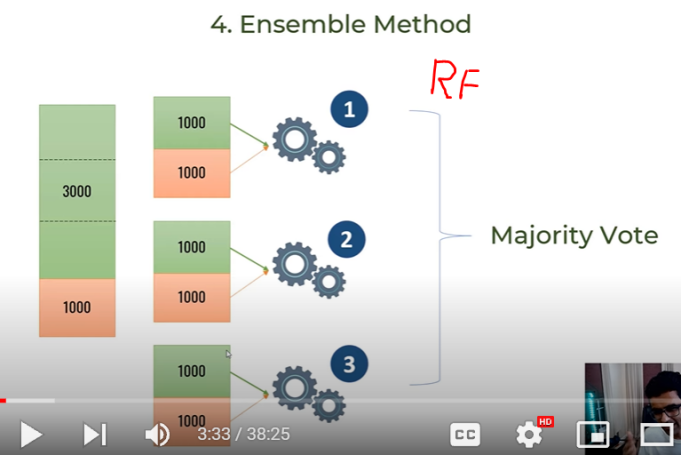

In [358]:
train.Churn.value_counts()

0    4130
1    1495
Name: Churn, dtype: int64

In [359]:
# Regain Original features and labels
X_train_Ens = train.drop('Churn',axis='columns')
y_train_Ens = train['Churn']


In [360]:
y_train_Ens.value_counts()

0    4130
1    1495
Name: Churn, dtype: int64

In [361]:
4130/1495   # 1:3 ratio means class 0 data is 3 times more than class 1 data. 

2.762541806020067

model1 --> class1(1495) + class0 (0 to 1495)

model2 --> class1(1495) + class0 (1496 to 2990)

model3 --> class1(1495) + class0 (2990 to 4130)

- Here we are only training model 3 time with 3 diffrent set of data and then take the max vote from the 3 as final result, It works like RF - Bagging method. But here we are manually splitting the data and passing here to build DL model

In [362]:
df3 = X_train_Ens.copy()
df3['Churn'] = y_train_Ens

In [363]:
df3.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
684,1,0,0,0,0.000000,1,0,0,0,0,...,1,0,1,0,0,0,0,0,1,0
2446,1,0,0,0,0.239437,1,1,0,1,0,...,1,0,1,0,0,0,1,0,0,1
1680,0,0,1,1,0.774648,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
2220,0,0,1,0,1.000000,1,0,1,1,0,...,0,0,0,0,1,1,0,0,0,0
2842,1,0,0,0,0.042254,0,0,1,0,1,...,0,0,1,0,0,0,0,0,1,0


In [364]:
df3_class0 = df3[df3.Churn==0]
df3_class1 = df3[df3.Churn==1]

In [365]:
# This will take sample majority data which we mentioned and combines with minority data and  split as X and Y
def get_train_batch(df_majority, df_minority, start, end):
    
    df_train = pd.concat([df_majority[start:end], df_minority], axis=0)

    X_train = df_train.drop('Churn', axis='columns')
    y_train = df_train.Churn
    print(X_train.shape)
    
    return X_train, y_train    

##  ENSEMBLE METHOD - ANN

In [366]:
# Train with 0 - 1495 Records

X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1495)

y_pred1 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

(2990, 26)
Epoch 1/100
94/94 [==============================] - 1s 1ms/step - loss: 0.5981 - accuracy: 0.7084
Epoch 2/100
94/94 [==============================] - 0s 1ms/step - loss: 0.5044 - accuracy: 0.7612
Epoch 3/100
94/94 [==============================] - 0s 861us/step - loss: 0.4878 - accuracy: 0.7679
Epoch 4/100
94/94 [==============================] - 0s 892us/step - loss: 0.4845 - accuracy: 0.7779
Epoch 5/100
94/94 [==============================] - 0s 897us/step - loss: 0.4812 - accuracy: 0.7732
Epoch 6/100
94/94 [==============================] - 0s 764us/step - loss: 0.4780 - accuracy: 0.7722
Epoch 7/100
94/94 [==============================] - 0s 968us/step - loss: 0.4768 - accuracy: 0.7763
Epoch 8/100
94/94 [==============================] - 0s 883us/step - loss: 0.4737 - accuracy: 0.7756
Epoch 9/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4719 - accuracy: 0.7776
Epoch 10/100
94/94 [==============================] - 0s 892us/step - loss: 0.4711 - a

94/94 [==============================] - 0s 887us/step - loss: 0.3980 - accuracy: 0.8120
Epoch 82/100
94/94 [==============================] - 0s 871us/step - loss: 0.3949 - accuracy: 0.8187
Epoch 83/100
94/94 [==============================] - 0s 886us/step - loss: 0.3941 - accuracy: 0.8187
Epoch 84/100
94/94 [==============================] - 0s 821us/step - loss: 0.3935 - accuracy: 0.8167
Epoch 85/100
94/94 [==============================] - 0s 850us/step - loss: 0.3942 - accuracy: 0.8167
Epoch 86/100
94/94 [==============================] - 0s 850us/step - loss: 0.3928 - accuracy: 0.8201
Epoch 87/100
94/94 [==============================] - 0s 905us/step - loss: 0.3923 - accuracy: 0.8161
Epoch 88/100
94/94 [==============================] - 0s 873us/step - loss: 0.3908 - accuracy: 0.8251
Epoch 89/100
94/94 [==============================] - 0s 860us/step - loss: 0.3909 - accuracy: 0.8154
Epoch 90/100
94/94 [==============================] - 0s 861us/step - loss: 0.3891 - accuracy: 

In [367]:
# Train with 1495 - 2990 Records
X_train, y_train = get_train_batch(df3_class0, df3_class1, 1495, 2990)

y_pred2 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

(2990, 26)
Epoch 1/100
94/94 [==============================] - 1s 1ms/step - loss: 0.6153 - accuracy: 0.6950
Epoch 2/100
94/94 [==============================] - 0s 1ms/step - loss: 0.5080 - accuracy: 0.7632
Epoch 3/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4935 - accuracy: 0.7599
Epoch 4/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4855 - accuracy: 0.7619
Epoch 5/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4833 - accuracy: 0.7666
Epoch 6/100
94/94 [==============================] - 0s 1ms/step - loss: 0.4790 - accuracy: 0.7712
Epoch 7/100
94/94 [==============================] - 0s 925us/step - loss: 0.4761 - accuracy: 0.7649
Epoch 8/100
94/94 [==============================] - 0s 857us/step - loss: 0.4742 - accuracy: 0.7672
Epoch 9/100
94/94 [==============================] - 0s 839us/step - loss: 0.4707 - accuracy: 0.7732
Epoch 10/100
94/94 [==============================] - 0s 989us/step - loss: 0.4682 - accurac

94/94 [==============================] - 0s 1ms/step - loss: 0.3904 - accuracy: 0.8181
Epoch 83/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3902 - accuracy: 0.8174
Epoch 84/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3871 - accuracy: 0.8184
Epoch 85/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3885 - accuracy: 0.8184
Epoch 86/100
94/94 [==============================] - 0s 991us/step - loss: 0.3885 - accuracy: 0.8161
Epoch 87/100
94/94 [==============================] - 0s 1ms/step - loss: 0.3873 - accuracy: 0.8161
Epoch 88/100
94/94 [==============================] - 0s 988us/step - loss: 0.3871 - accuracy: 0.8194
Epoch 89/100
94/94 [==============================] - 0s 964us/step - loss: 0.3858 - accuracy: 0.8194
Epoch 90/100
94/94 [==============================] - 0s 925us/step - loss: 0.3849 - accuracy: 0.8174
Epoch 91/100
94/94 [==============================] - 0s 969us/step - loss: 0.3877 - accuracy: 0.8204
Epo

In [368]:
# Train with 2990 - 4130 Records
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2990, 4130)

y_pred3 = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

(2635, 26)
Epoch 1/100
83/83 [==============================] - 0s 970us/step - loss: 0.5997 - accuracy: 0.6816
Epoch 2/100
83/83 [==============================] - 0s 1ms/step - loss: 0.5044 - accuracy: 0.7620
Epoch 3/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4909 - accuracy: 0.7643
Epoch 4/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4848 - accuracy: 0.7685
Epoch 5/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4804 - accuracy: 0.7738
Epoch 6/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4771 - accuracy: 0.7731
Epoch 7/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4731 - accuracy: 0.7761
Epoch 8/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4707 - accuracy: 0.7704
Epoch 9/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4658 - accuracy: 0.7799
Epoch 10/100
83/83 [==============================] - 0s 1ms/step - loss: 0.4663 - accuracy: 0.7

83/83 [==============================] - 0s 1ms/step - loss: 0.3647 - accuracy: 0.8342
Epoch 82/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3630 - accuracy: 0.8361
Epoch 83/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3634 - accuracy: 0.8338
Epoch 84/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3626 - accuracy: 0.8326
Epoch 85/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3616 - accuracy: 0.8376
Epoch 86/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3585 - accuracy: 0.8387
Epoch 87/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3593 - accuracy: 0.8334
Epoch 88/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3569 - accuracy: 0.8383
Epoch 89/100
83/83 [==============================] - 0s 993us/step - loss: 0.3578 - accuracy: 0.8349
Epoch 90/100
83/83 [==============================] - 0s 1ms/step - loss: 0.3566 - accuracy: 0.8433
Epoch 91/10

In [369]:
y_pred1.shape, y_pred2.shape, y_pred3.shape

((1407, 1), (1407, 1), (1407, 1))

### Majority vote

- Here outof 3 if more than ONE having vote = 1 then its 1, else its 0 
- So we are summing up all votes, if sum>1 then 1 else 0

In [370]:
y_pred_final = y_pred1.copy()

for i in range(len(y_pred1)):
    n_ones = y_pred1[i] + y_pred2[i] + y_pred3[i]
    if n_ones>1:
        y_pred_final[i] = 1
    else:
        y_pred_final[i] = 0

In [371]:
cl_rep = classification_report(y_test, y_pred_final)
print(cl_rep)

              precision    recall  f1-score   support

         0.0       0.89      0.71      0.79      1033
         1.0       0.48      0.75      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.72      0.74      1407



f1-score for minority class 1 improved to 0.81 from 0.57. The score for majority class 0 is suffering and reduced to 0.78 from 0.85 but at least there is some balance in terms of prediction accuracy across two classes

In [372]:
# f1-score is very imp when dataset is imbalanced. Overall SMOTE performed very well.

##  ENSEMBLE METHOD - Log Reg

In [373]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 0, 1495)

y_pred_log1 = log_reg(X_train, y_train, X_test, y_test, -1)

(2990, 26)
Accuracy 0.7476901208244492 

preds [0 0 0 0 1] 

              precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1033
         1.0       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [374]:
X_train, y_train = get_train_batch(df3_class0, df3_class1,  1495, 2990)

y_pred_log2 = log_reg(X_train, y_train, X_test, y_test, -1)

(2990, 26)
Accuracy 0.7377398720682303 

preds [0 0 0 0 1] 

              precision    recall  f1-score   support

         0.0       0.91      0.72      0.80      1033
         1.0       0.50      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [375]:
X_train, y_train = get_train_batch(df3_class0, df3_class1, 2990, 4130)

y_pred_log3 = log_reg(X_train, y_train, X_test, y_test, -1)

(2635, 26)
Accuracy 0.6965174129353234 

preds [0 0 0 0 1] 

              precision    recall  f1-score   support

         0.0       0.92      0.65      0.76      1033
         1.0       0.46      0.84      0.59       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.80      0.70      0.71      1407



### Majority vote

- Here outof 3 if more than ONE having vote = 1 then its 1, else its 0 
- So we are summing up all votes, if sum>1 then 1 else 0

In [376]:
y_pred_final_log = y_pred_log1.copy()

for i in range(len(y_pred1)):
    n_ones = y_pred_log1[i] + y_pred_log2[i] + y_pred_log3[i]
    if n_ones>1:
        y_pred_final_log[i] = 1
    else:
        y_pred_final_log[i] = 0

In [377]:
y_pred_final_log

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

In [378]:
cl_rep_log = classification_report(y_test, y_pred_final_log)
print(cl_rep_log)

              precision    recall  f1-score   support

         0.0       0.91      0.71      0.80      1033
         1.0       0.50      0.80      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407



### Conclusion:  ANN looks gave very good f1 rate in SMOTE , Logistic regression didnt give good F1 score after Under, uver sampling or smote or ensembel method